## Segmentation

простая демонстрационная программа для сегментации на PyTorch, которая:

загружает предобученную модель segmentation_models.pytorch
делает inference
визуализирует оригинал + маску

Мы используем DeepLabV3 (pretrained) — это стандартный быстрый вариант.

DeepLabV3 использует:

atrous convolutions

spatial pyramid pooling

pretrained backbone (ResNet50)

DeepLabV3 и YOLO — это две разные архитектуры нейронных сетей, предназначенные для решения различных задач в компьютерном зрении. DeepLabV3 специализируется на семантической сегментации, то есть классификации каждого пикселя изображения по категориям (например, «дорога», «здание», «человек»). YOLO (You Only Look Once) ориентирован на обнаружение объектов — определение местоположения объектов на изображении и их классификацию с помощью ограничивающих рамок. 

## Шаг 1. Установка зависимостей

In [6]:
#!pip install torch torchvision segmentation-models-pytorch matplotlib pillow

## Код программы

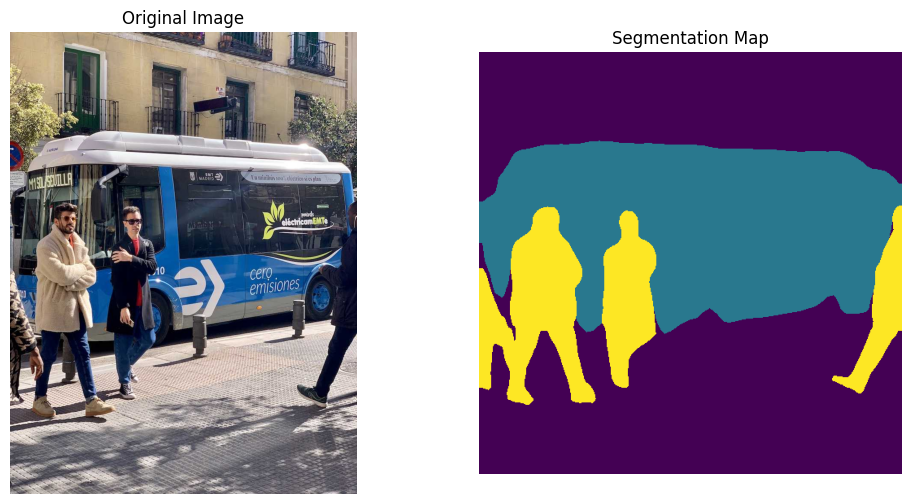

In [5]:
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ----------------------------
# 1. Загружаем pretrained DeepLabV3
# ----------------------------
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
model.eval()

# ----------------------------
# 2. Загружаем изображение
# ----------------------------
image_path = "bus.jpg"  # <-- твое изображение


image = Image.open(image_path).convert("RGB")

# ----------------------------
# 3. Preprocessing (ВАЖНО: ImageNet normalization)
# ----------------------------
transform = T.Compose([
    T.Resize((520, 520)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

x = transform(image).unsqueeze(0)

# ----------------------------
# 4. Inference
# ----------------------------
with torch.no_grad():
    output = model(x)["out"][0]  # [C, H, W]

# ----------------------------
# 5. Получаем класс для каждого пикселя
# ----------------------------
seg = torch.argmax(output, dim=0).cpu().numpy()

# ----------------------------
# 6. Визуализация
# ----------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Segmentation Map")
plt.imshow(seg)
plt.axis("off")

plt.show()